<a href="https://colab.research.google.com/github/valentasman538-byte/Bird-Classification/blob/main/Bird_classification_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [2]:
!pip install resampy
import os

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.image as mpimg
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from glob import glob

# Libraries for processing sounds
import librosa
import librosa.display
import IPython.display as ipd
import soundfile as sf
import sklearn
import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 38.2 MB/s eta 0:00:00


# Import CSV

In [3]:
import kagglehub
path = kagglehub.dataset_download("soumendraprasad/sound-of-114-species-of-birds-till-2022")

100%|██████████| 2.06G/2.06G [00:39<00:00, 56.8MB/s]

Extracting files...


In [4]:
train_csv= pd.read_csv(os.path.join(path, "Birds Voice.csv"))

# Create some time features
train_csv['year'] = train_csv['Date'].apply(lambda x: x.split('-')[0])
train_csv['month'] = train_csv['Date'].apply(lambda x: x.split('-')[1])
train_csv['day_of_month'] = train_csv['Date'].apply(lambda x: x.split('-')[2])

print("There are {:,} unique bird species in the dataset.".format(len(train_csv['common_name'].unique())))
train_csv.head()

There are 114 unique bird species in the dataset.


,common_name,scientific_name,recordist_name,recording_length,Date,TYPE,xc_id,Time,Country,Download_link,year,month,day_of_month
0,Common Ostrich,Struthio camelus australis,Frank Lambert,0:53,2019-10-30,call,XC516153,08:05,South Africa,https://xeno-canto.org/516153/download,2019,10,30
1,Common Ostrich,Struthio camelus,Jeremy Hegge,0:26,2014-11-20,call,XC208209,04:00,South Africa,https://xeno-canto.org/208209/download,2014,11,20
2,Common Ostrich,Struthio camelus,Jeremy Hegge,0:04,2014-11-21,call,XC208128,06:00,South Africa,https://xeno-canto.org/208128/download,2014,11,21
3,Common Ostrich,Struthio camelus,Derek Solomon,0:11,2010-02-09,call,XC46725,07:00,South Africa,https://xeno-canto.org/46725/download,2010,02,09
4,Common Ostrich,Struthio camelus,Morioka Zoological Park ZOOMO,1:47,2021-09-06,"voice during egg laying, zoo collection",XC675445,17:00,Japan,https://xeno-canto.org/675445/download,2021,09,06


In [5]:
bird_species_counts = train_csv['common_name'].value_counts().reset_index()
bird_species_counts.columns = ['Bird Species', 'Count']

# Filter for bird species with a count greater than 10
filtered_bird_species_counts = bird_species_counts[bird_species_counts['Count'] > 10]

print("List of common bird species with more than 10 recordings:")
print(filtered_bird_species_counts)

List of common bird species with more than 10 recordings:
                 Bird Species  Count
0               Great Tinamou     30
1            Solitary Tinamou     30
2      White-throated Tinamou     30
3                Grey Tinamou     30
4        Small-billed Tinamou     30
..                        ...    ...
75      Chestnut-bellied Guan     12
76  Black-fronted Piping Guan     12
77         White-crested Guan     12
78        Melanesian Megapode     12
79             Ornate Tinamou     12

[80 rows x 2 columns]


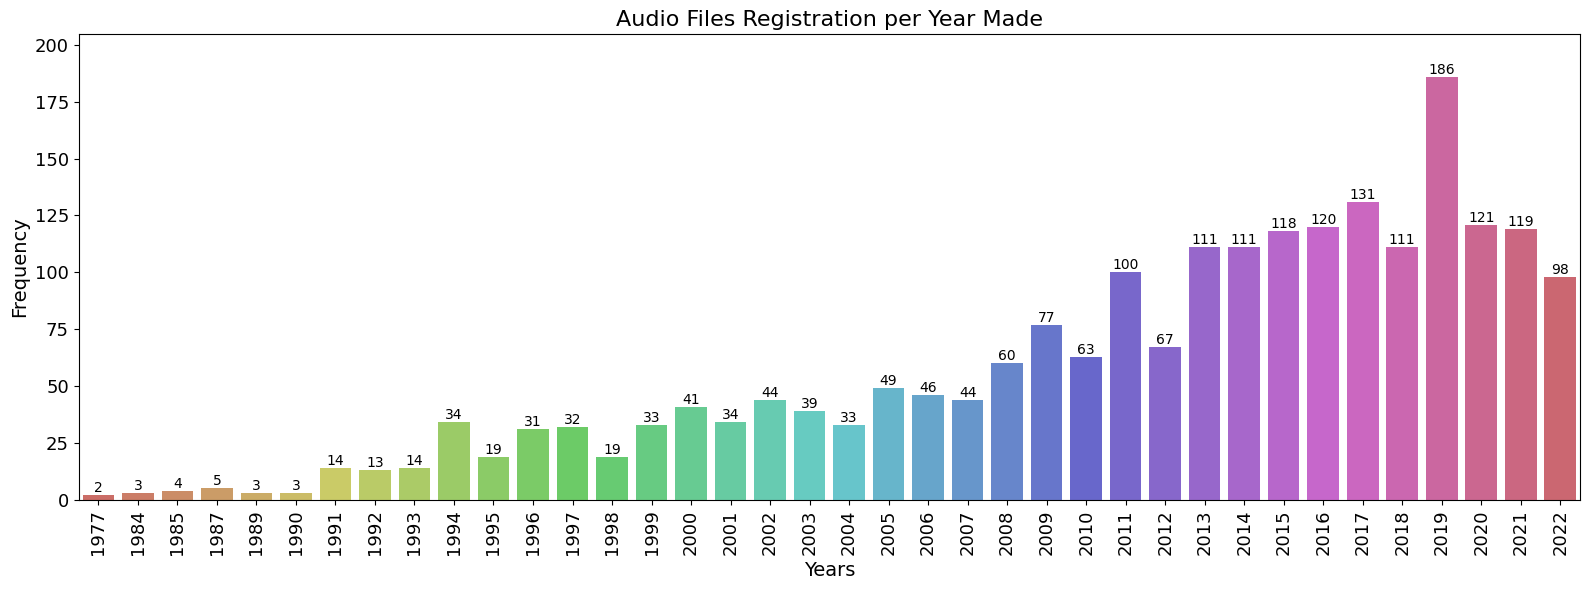

In [6]:
plt.figure(figsize=(16, 6)) # Adjust figure size for vertical bars

# Filter out '0000' from the year column
filtered_train_csv = train_csv[train_csv['year'] != '0000']

# Order the years chronologically
year_order = sorted(filtered_train_csv['year'].unique())

ax = sns.countplot(data=filtered_train_csv, x='year', palette="hls", order=year_order) # Set 'year' to x-axis

plt.title("Audio Files Registration per Year Made", fontsize=16)
plt.xticks(rotation=90, fontsize=13) # Rotate x-axis labels for readability
plt.yticks(fontsize=13)
plt.ylabel("Frequency", fontsize=14) # Y-axis is now frequency
plt.xlabel("Years", fontsize=14) # X-axis is now years

# Add count labels on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10)

# Adjust y-axis limit to make space for labels
ax.margins(y=0.1) # Add 10% margin on top

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

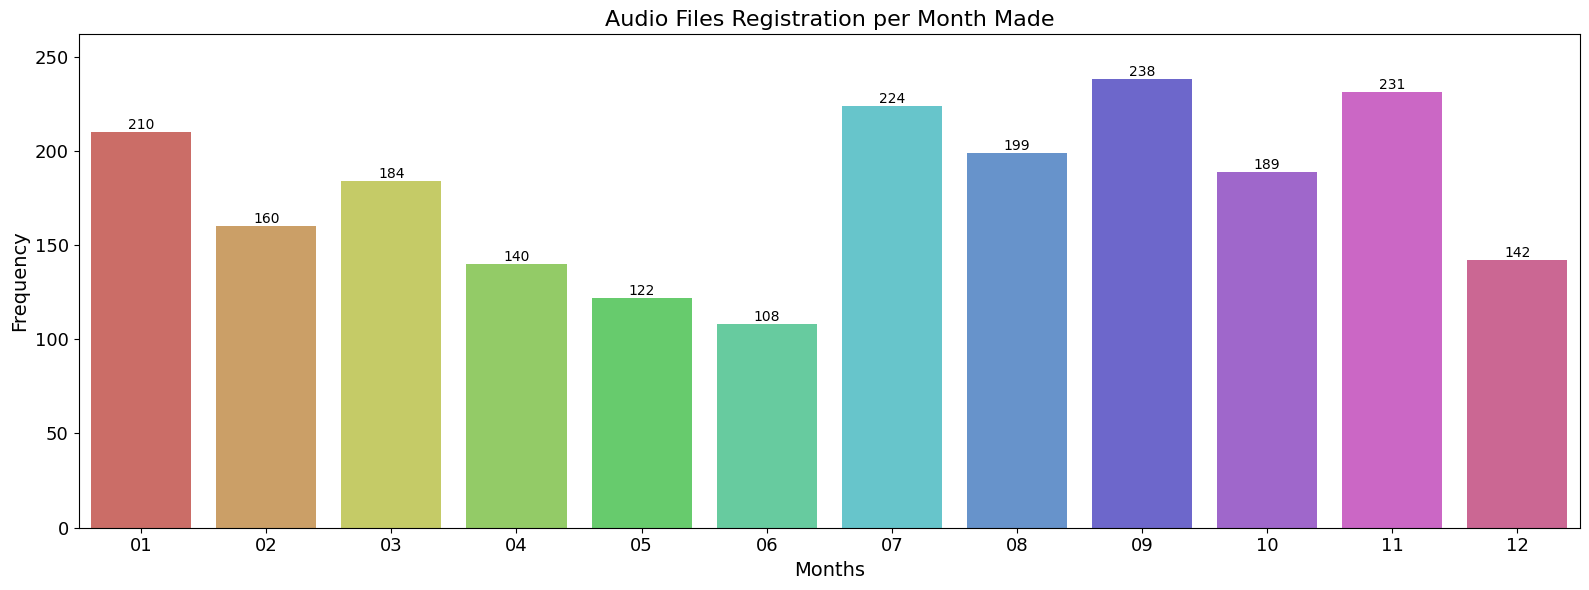

In [7]:
plt.figure(figsize=(16, 6))

# Filter out '00' from the month column
filtered_train_csv_month = train_csv[train_csv['month'] != '00']

# Order months chronologically (1-12)
month_order = sorted(filtered_train_csv_month['month'].unique())

ax = sns.countplot(data=filtered_train_csv_month, x='month', palette="hls", order=month_order)

plt.title("Audio Files Registration per Month Made", fontsize=16)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.ylabel("Frequency", fontsize=14) # Corrected y-axis label
plt.xlabel("Months", fontsize=14); # Corrected x-axis label

# Add count labels on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10)

# Adjust y-axis limit to make space for labels
ax.margins(y=0.1) # Add 10% margin on top

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

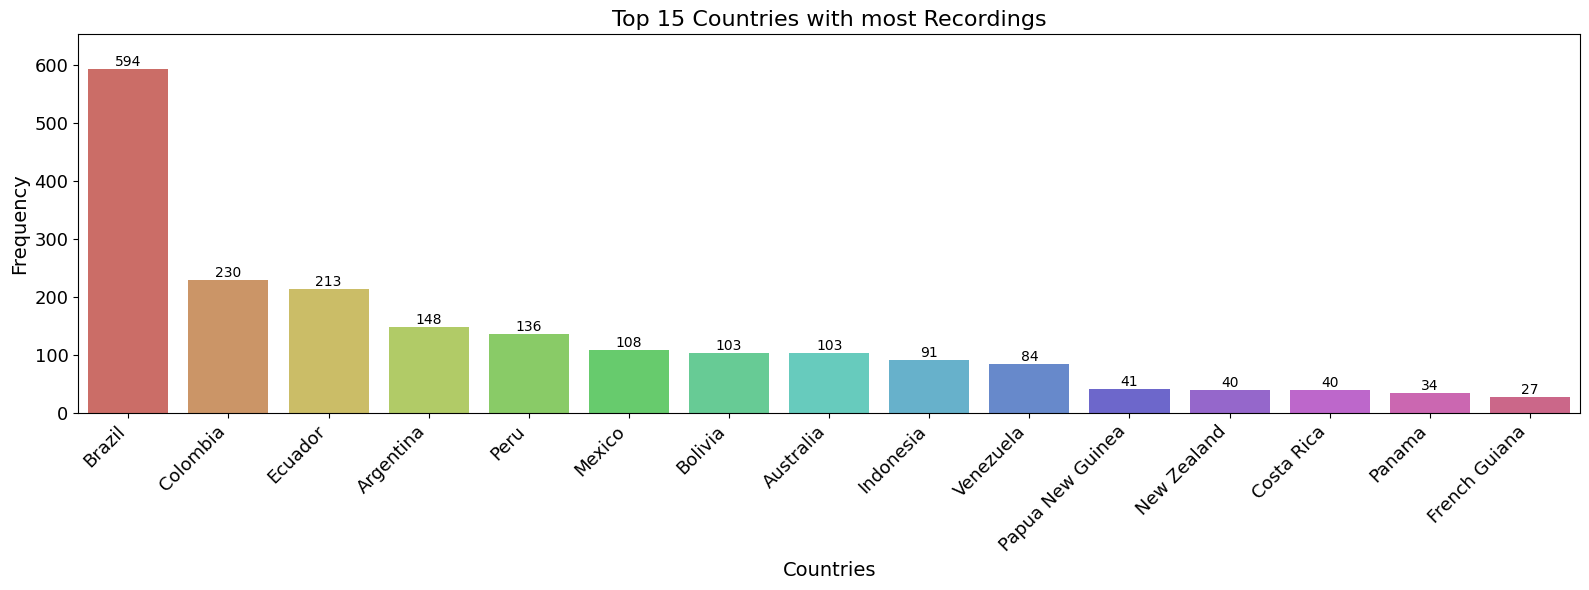

In [8]:
top_15 = list(train_csv['Country'].value_counts().head(15).reset_index()['Country'])
data = train_csv[train_csv['Country'].isin(top_15)]

plt.figure(figsize=(16, 6)) # Adjusted figure size for vertical bars
ax = sns.countplot(data=data, x='Country', palette='hls', order = data['Country'].value_counts().index)

plt.title("Top 15 Countries with most Recordings", fontsize=16)
plt.xlabel("Countries", fontsize=14) # X-axis is now Countries
plt.xticks(rotation=45, ha='right', fontsize=13) # Rotate x-axis labels for readability
plt.yticks(fontsize=13)
plt.ylabel("Frequency", fontsize=14); # Y-axis is now Frequency

# Add count labels on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10)

# Adjust y-axis limit to make space for labels
ax.margins(y=0.1) # Add 10% margin on top

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [9]:
# Checking null values
train_csv.isnull().sum()

,0
common_name,0
scientific_name,0
recordist_name,0
recording_length,0
Date,0
TYPE,31
xc_id,0
Time,0
Country,0
Download_link,0


In [10]:
# unique name of persons who recorded
train_csv['recordist_name'].nunique()

449

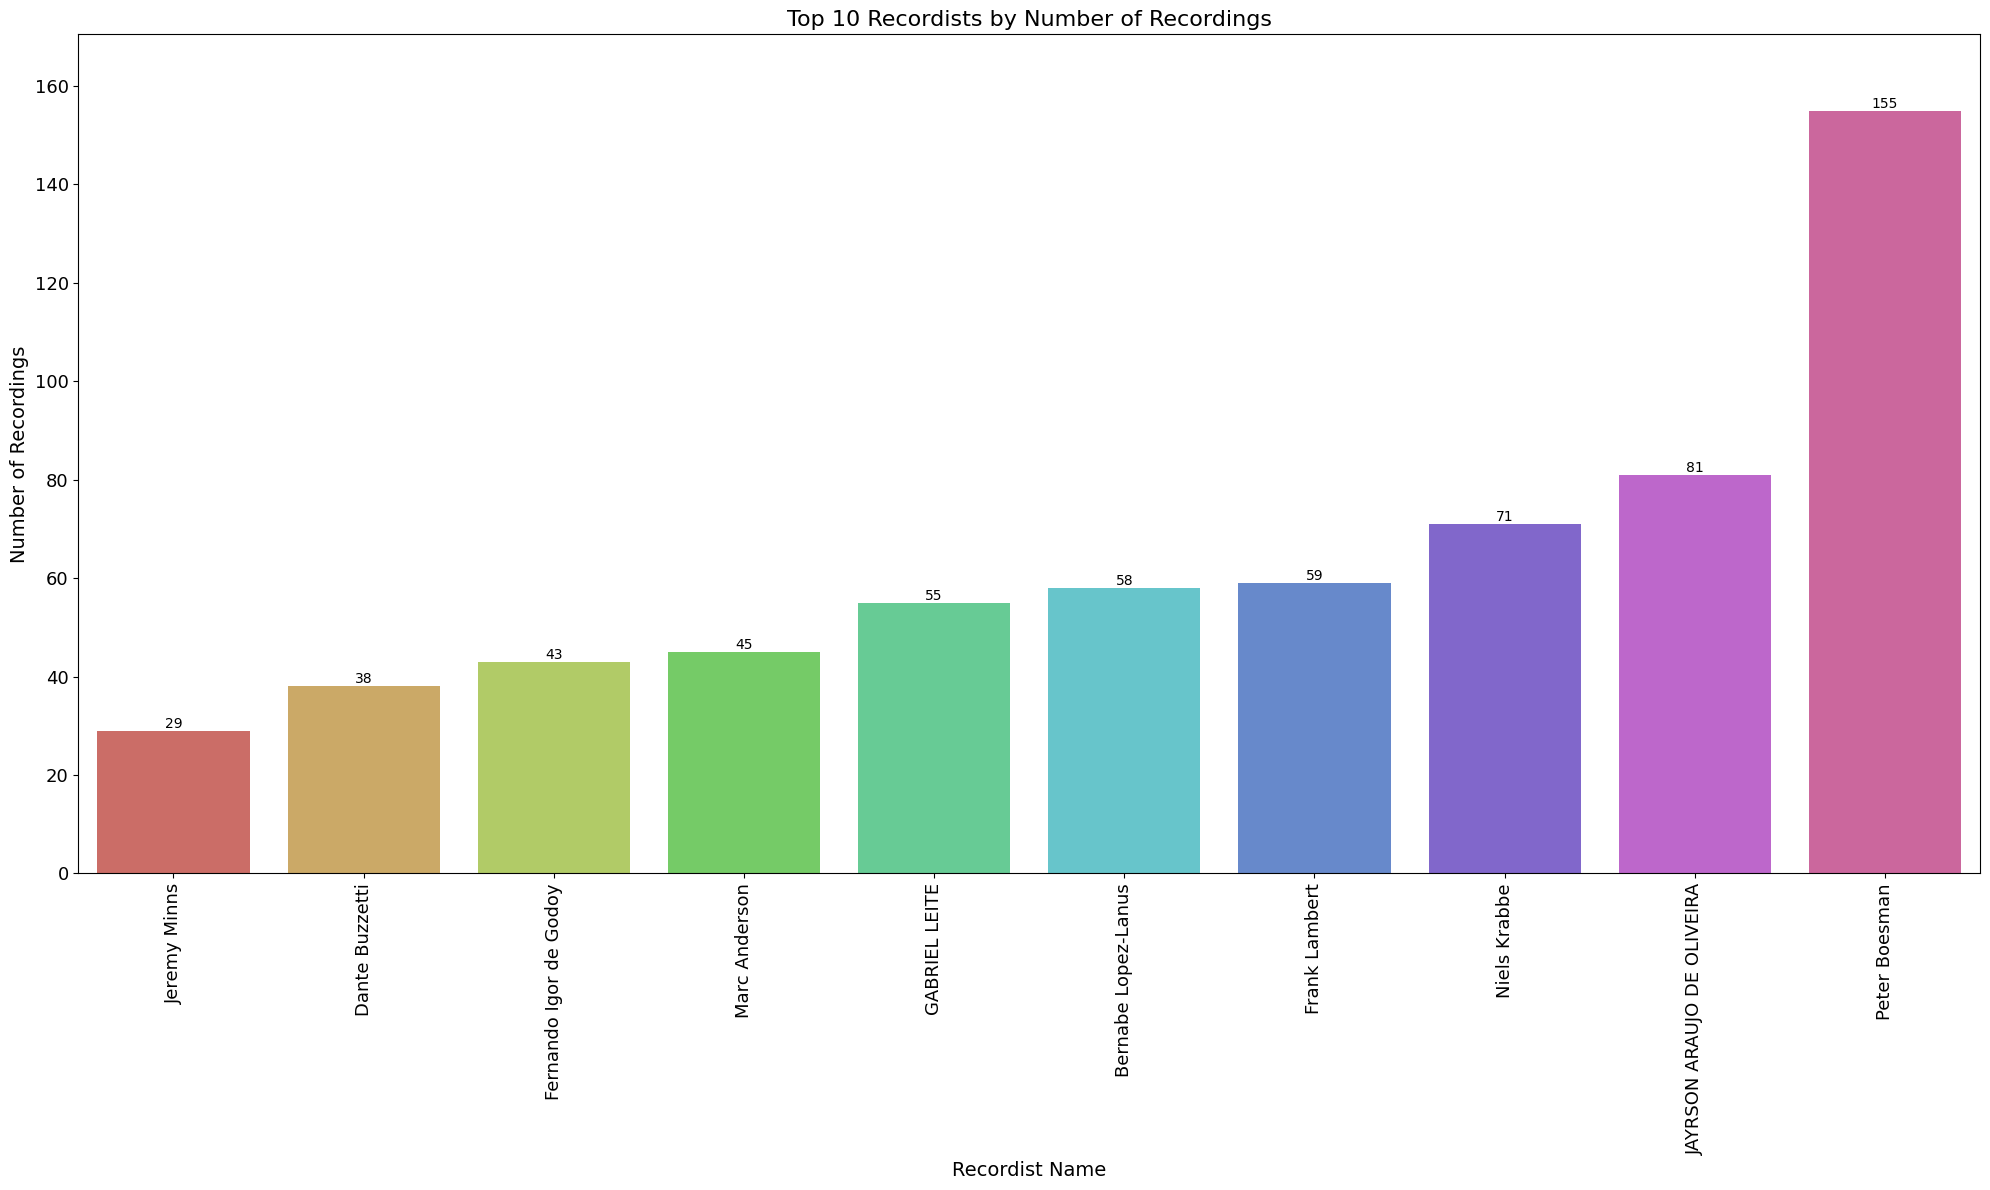

In [11]:
plt.figure(figsize=(20,12))
# We will use the top 10 recordists, ordered by count (ascending)
top_10_recordists = train_csv['recordist_name'].value_counts().nlargest(10).sort_values(ascending=True).index
ax = sns.countplot(data=train_csv, x='recordist_name', palette='hls', order=top_10_recordists)

plt.title("Top 10 Recordists by Number of Recordings", fontsize=16)
plt.xlabel("Recordist Name", fontsize=14) # X-axis is now recordist name
plt.ylabel("Number of Recordings", fontsize=14) # Y-axis is now frequency

# Rotate x-axis labels for readability
plt.xticks(rotation=90, fontsize=13)
plt.yticks(fontsize=13)

# Add count labels on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10)

# Adjust y-axis limit to make space for labels
ax.margins(y=0.1) # Add 10% margin on top

plt.tight_layout()
plt.show()

In [12]:
audio_file1=glob(os.path.join(path, "Voice of Birds", "Voice of Birds", "Australian Brushturkey_sound", "*.mp3"))

In [13]:
#Playing an audio file

ipd.Audio(audio_file1[10])

In [14]:
ipd.Audio(audio_file1[5])

In [15]:
# Extracting the data & sample rate from audio file

Data,sr = librosa.load(audio_file1[9])
Australian_Brushturkey_AudioData= Data
print('Data:', Data, '\n')
print('Data shape:', np.shape(Data), '\n')
print('Sample Rate (KHz):', sr, '\n')

# Verify length of the audio
print('Check Len of Audio:', np.shape(Data)[0]/sr)

Data: [-0.0585423  -0.10690291 -0.11289749 ... -0.07165346 -0.06732436
 -0.07093383] 

Data shape: (703686,) 

Sample Rate (KHz): 22050 

Check Len of Audio: 31.913197278911564


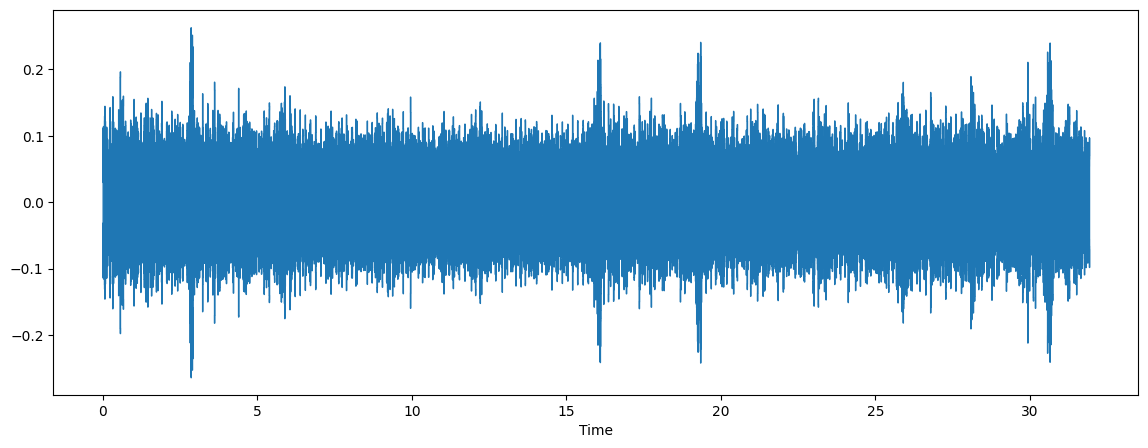

In [16]:
plt.figure(figsize=(14, 5))
librosa.display.waveshow(Australian_Brushturkey_AudioData, sr=sr,x_axis="time")

In [17]:
# Trim leading and trailing silence from an audio signal (silence before and after the actual audio)
trimmed_audiofile, sr_trimmed_audiofile = librosa.effects.trim(Australian_Brushturkey_AudioData,top_db=23)

# the result is an numpy ndarray
print('Audio File:', trimmed_audiofile, '\n')
print('Audio File shape:', np.shape(trimmed_audiofile))

Audio File: [-0.0585423  -0.10690291 -0.11289749 ... -0.07165346 -0.06732436
 -0.07093383] 

Audio File shape: (703686,)


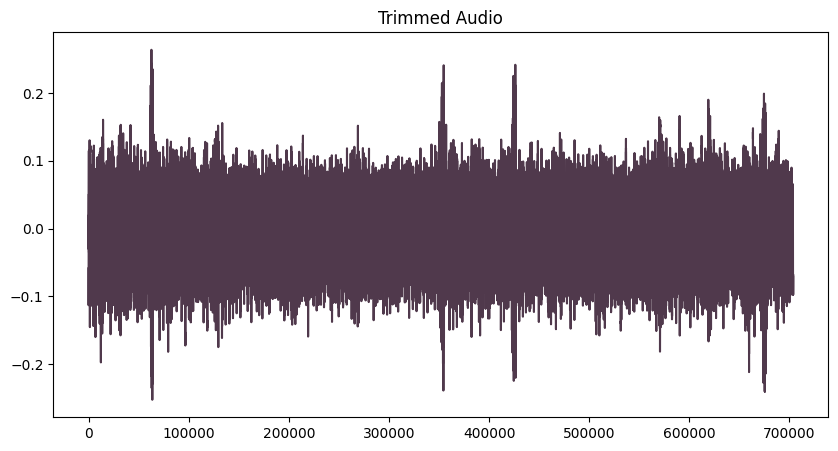

In [18]:
pd.Series(trimmed_audiofile).plot(figsize=(10,5),
                                  title="Trimmed Audio",
                                  color="#50394c")
plt.show()

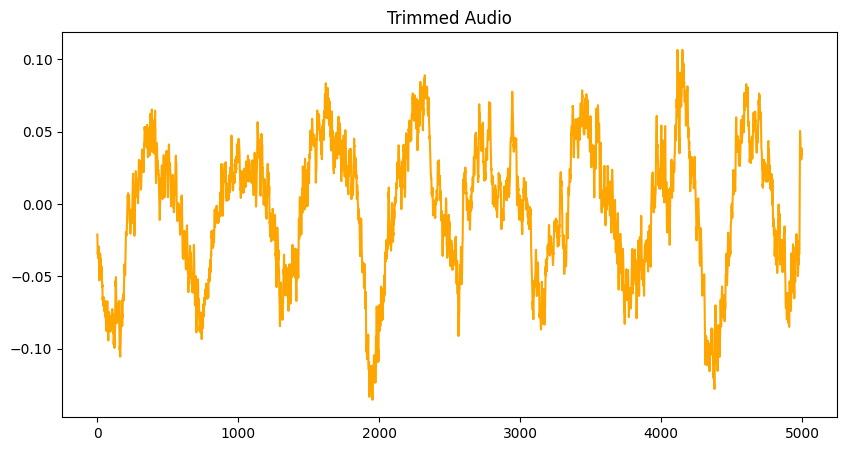

In [19]:
pd.Series(Australian_Brushturkey_AudioData[25000:30000
               ]).plot(figsize=(10,5),
                                  title="Trimmed Audio",
                                  color="orange")
plt.show()

# Classical FFT

In [20]:
# implementing fft
raw_audio_fft=np.fft.fft(Australian_Brushturkey_AudioData)
raw_audio_fft.shape

(703686,)

In [21]:
raw_audio_fft[0]

np.complex64(-59.797142-2.6201263e-14j)

In [22]:
magnitude=np.abs(raw_audio_fft)

In [23]:
# Now we successfully discarded the compl
magnitude[1]

np.float32(13.958052)

In [24]:
def plot_manitude_spectrum(signal,title,sr):
    ft=np.fft.fft(signal)
    magnitude_spectrum=np.abs(ft)

    #plot
    plt.figure(figsize=(16,5))
    frequency=np.linspace(0,sr,len(magnitude_spectrum))
    plt.plot(frequency,magnitude_spectrum)
    plt.xlabel("frequency{Hz}")
    plt.title(title)

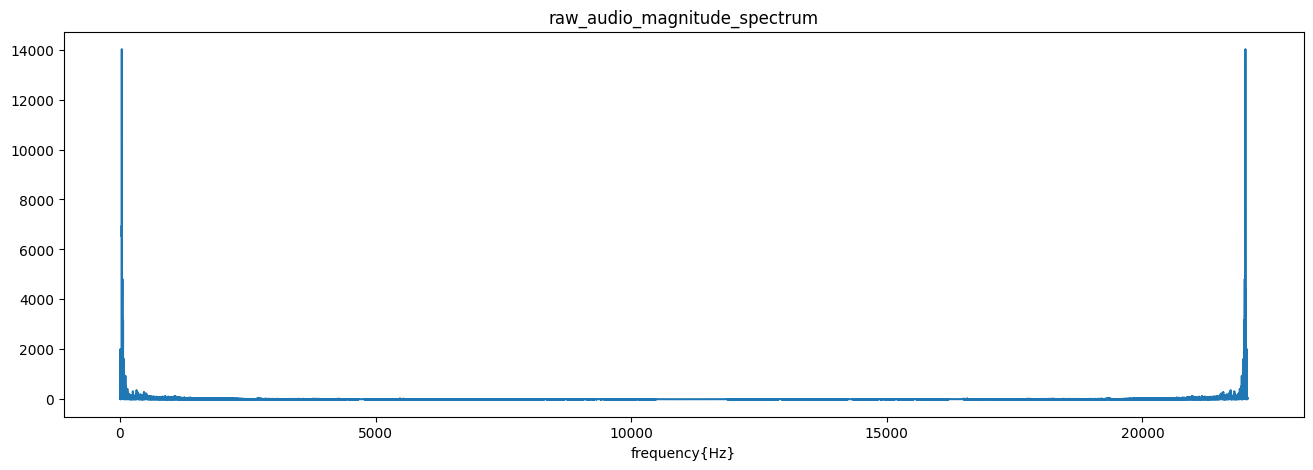

In [25]:
plot_manitude_spectrum(Australian_Brushturkey_AudioData,"raw_audio_magnitude_spectrum",sr)

# Short-Time Fourier Transform

In [26]:
# Extracting STFt

FRAME_SIZE=2048
HOP_SIZE=512

In [27]:
S_SCALE=librosa.stft(Australian_Brushturkey_AudioData,n_fft=FRAME_SIZE,hop_length=HOP_SIZE)
S_SCALE.shape

(1025, 1375)

In [28]:
type(S_SCALE[0][0])

numpy.complex64

# Spectogram

In [29]:
Spec_scale=np.abs(S_SCALE)**2
print(Spec_scale.shape)
print(type(Spec_scale[0][0]))

(1025, 1375)
<class 'numpy.float32'>


In [30]:
# Visualizing Spectogram
def plot_spec(y,sr,hop_length,y_axis="linear"):

    plt.figure(figsize=(16,6))
    librosa.display.specshow(
                    y,
                    sr=sr,
                    hop_length=hop_length,
                    x_axis="time",
                    y_axis=y_axis)

    plt.colorbar()

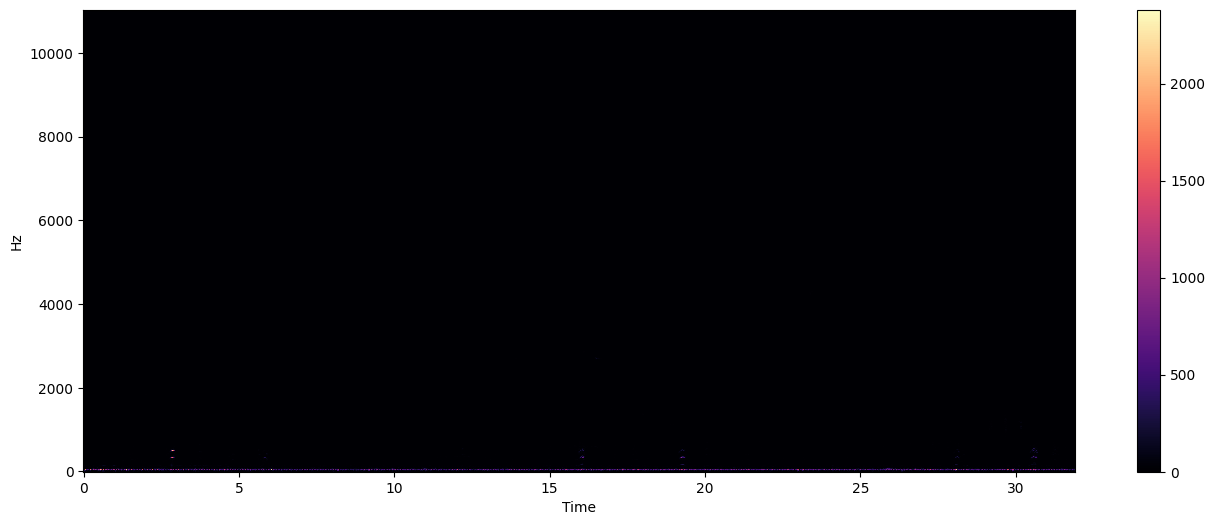

In [31]:
plot_spec(Spec_scale,sr,HOP_SIZE)

## Log-Amplitude Spectogram

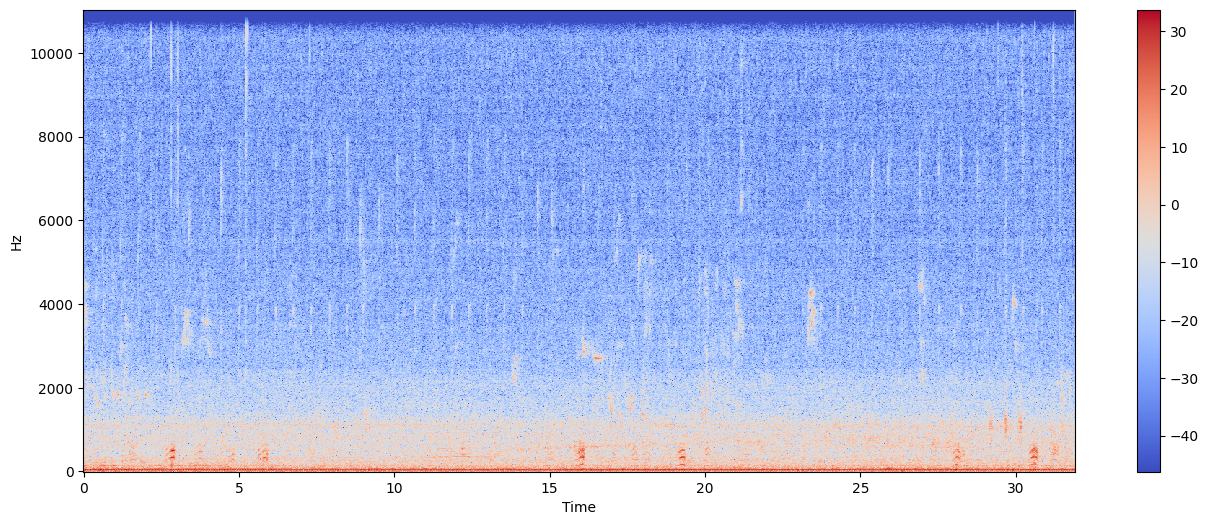

In [32]:
y_log_scale=librosa.power_to_db(Spec_scale)
plot_spec(y_log_scale,sr,HOP_SIZE)

## Log-Frequency Spectrum

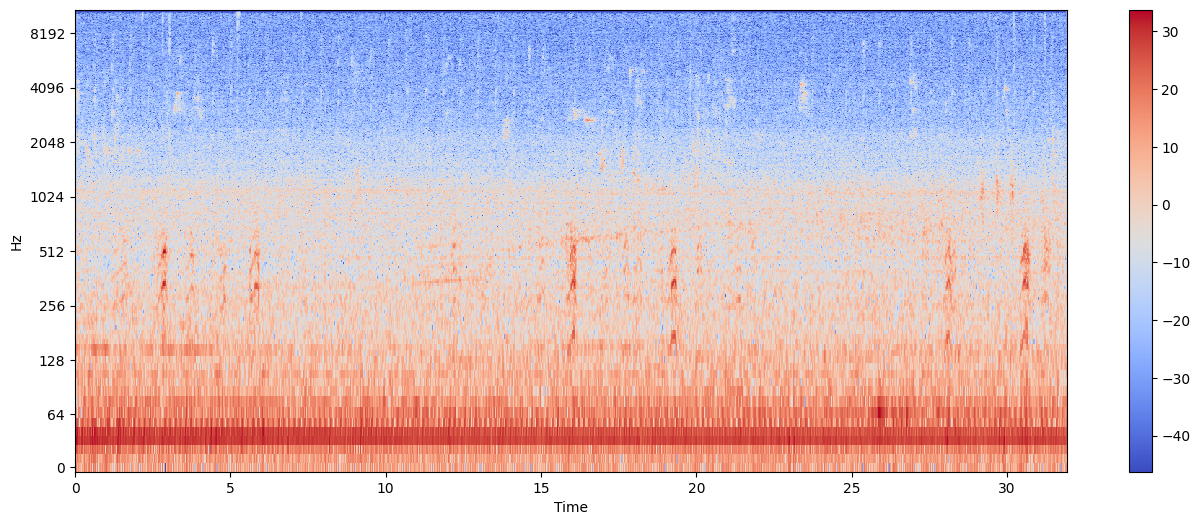

In [33]:
plot_spec(y_log_scale,sr,HOP_SIZE,y_axis='log')

## Mel Filter Banks

In [34]:
filter_bank=librosa.filters.mel(n_fft=2048,sr=22050,n_mels=10)
filter_bank.shape

(10, 1025)

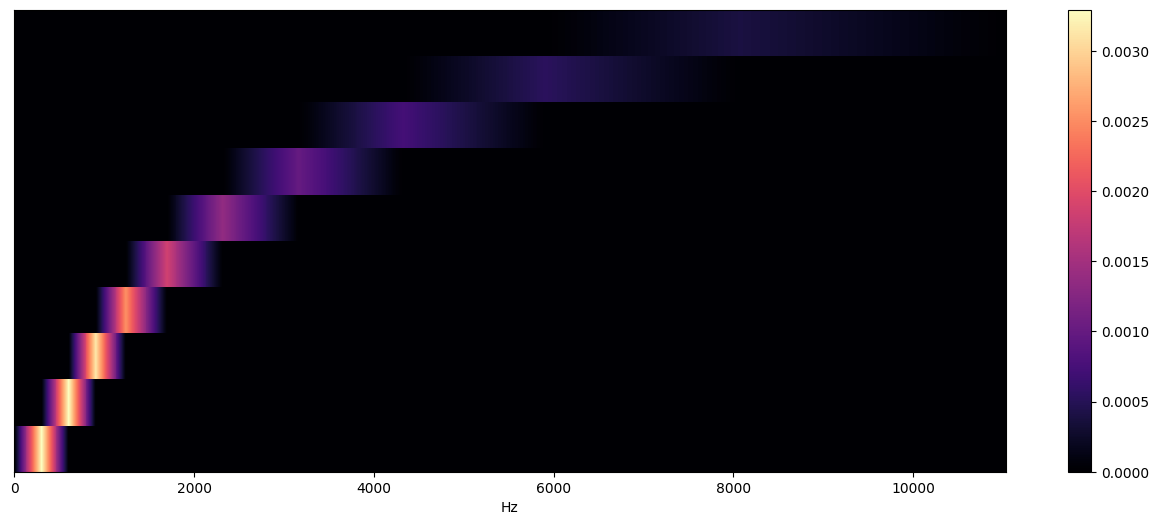

In [35]:
plt.figure(figsize=(16,6))
librosa.display.specshow(
                    filter_bank,
                    sr=sr,
                    x_axis="linear")
plt.colorbar()

## Mel Spectogram

In [36]:
mel_spec=librosa.feature.melspectrogram(y=Australian_Brushturkey_AudioData,sr=sr,n_fft=2048,hop_length=512,n_mels=90)
mel_spec.shape

(90, 1375)

In [37]:
log_mel_spectogram=librosa.power_to_db(mel_spec)
log_mel_spectogram.shape

(90, 1375)

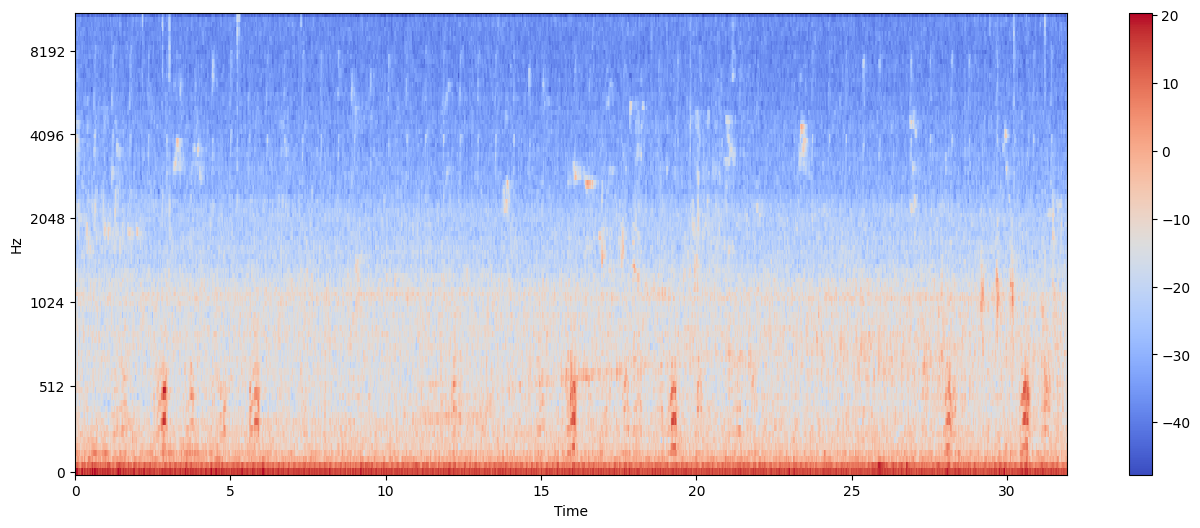

In [38]:
plt.figure(figsize=(16,6))
librosa.display.specshow(
                    log_mel_spectogram,
                    sr=sr,
                    x_axis="time",
                    y_axis="mel")
plt.colorbar()

# Feature Extraction Methods

## **Zero** Crossing Rate

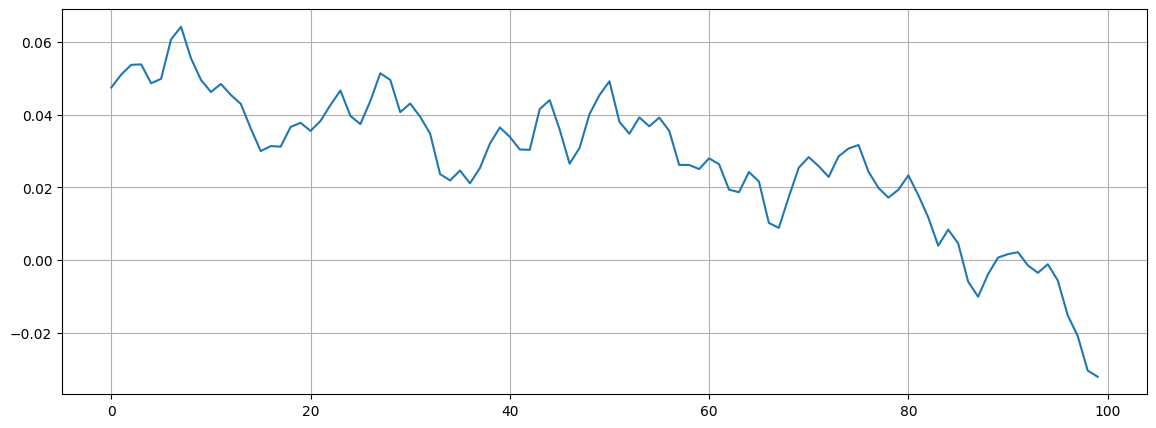

In [39]:
n0 = 9000
n1 = 9100
plt.figure(figsize=(14, 5))
plt.plot(Australian_Brushturkey_AudioData[n0:n1])
plt.grid()

In [40]:
zero_crossings = librosa.zero_crossings(Australian_Brushturkey_AudioData[n0:n1], pad=False)
print(sum(zero_crossings))

3


In [41]:
spectral_centroids = librosa.feature.spectral_centroid(y=Australian_Brushturkey_AudioData, sr=sr)[0]
spectral_centroids.shape

(1375,)

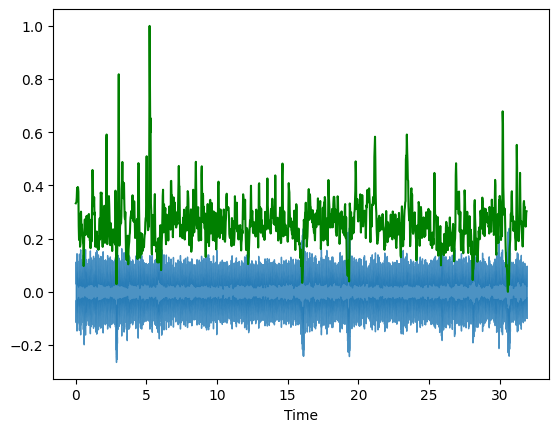

In [42]:
# Visualizing

frames = range(len(spectral_centroids))
t = librosa.frames_to_time(frames)
# Normalising the spectral centroid for visualisation
def normalize(x, axis=0):
    return sklearn.preprocessing.minmax_scale(x, axis=axis)
#Plotting the Spectral Centroid along the waveform
librosa.display.waveshow(Australian_Brushturkey_AudioData, sr=sr, alpha=0.8)
plt.plot(t, normalize(spectral_centroids), color='g')

## Chroma Features

Chromogram Australian Brushturkey: (12, 352)


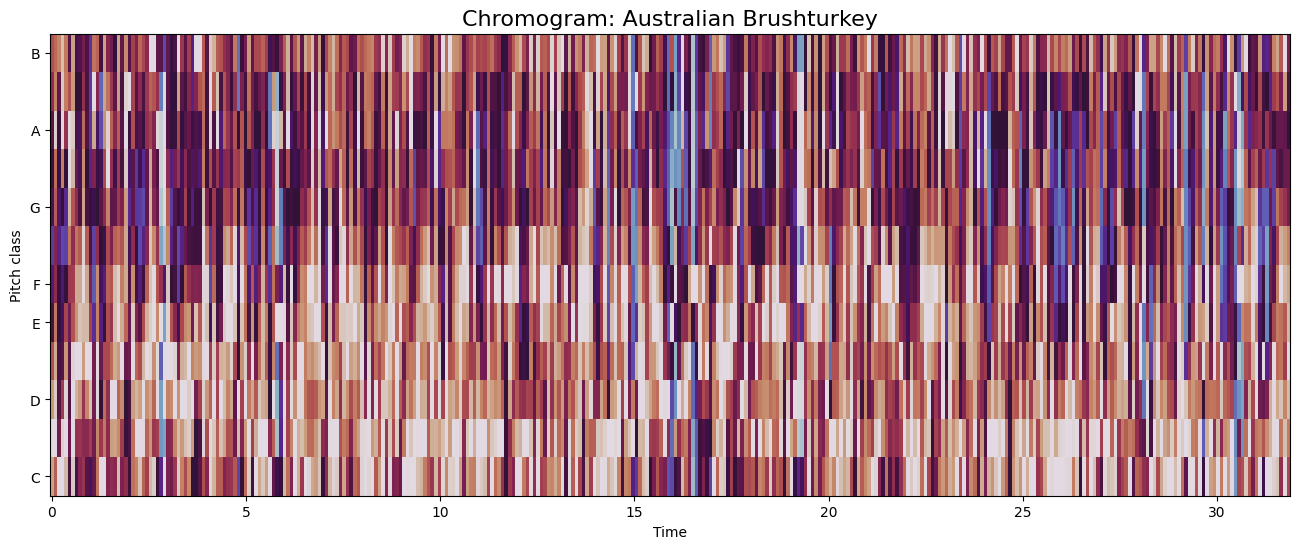

In [43]:
hop_length = 2000
chromagram = librosa.feature.chroma_stft(y=trimmed_audiofile, sr=sr, hop_length=hop_length)
print('Chromogram Australian Brushturkey:', chromagram.shape)

plt.figure(figsize=(16, 6))
librosa.display.specshow(chromagram, x_axis='time', y_axis='chroma', hop_length=hop_length, cmap='twilight')

plt.title("Chromogram: Australian Brushturkey", fontsize=16);

## Mel-Frequency Cepstral Coefficients(MFCCs)

In [44]:
mfccs = librosa.feature.mfcc(y=Australian_Brushturkey_AudioData, sr=sr)
print(mfccs.shape)

(20, 1375)


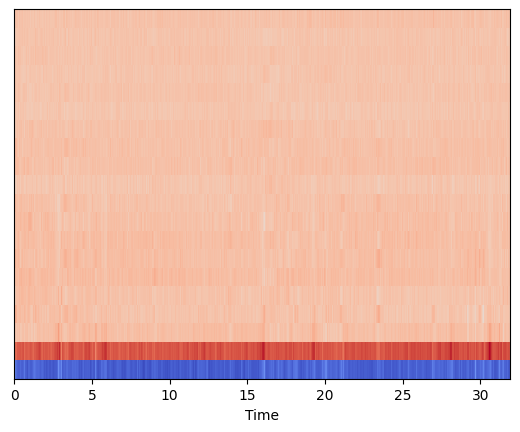

In [45]:
#Visualizing  the MFCCs:
librosa.display.specshow(mfccs, sr=sr, x_axis='time')

[ 0.0000000e+00  0.0000000e+00 -5.5486504e-09  5.5486504e-09
 -1.1097301e-08 -1.1097301e-08  0.0000000e+00  1.6645952e-08
 -1.8033115e-08  0.0000000e+00  8.3229761e-09  5.5486504e-09
 -6.9358133e-09  8.3229761e-09  4.1614880e-09  1.1097301e-08
 -1.1097301e-08  5.5486504e-09  0.0000000e+00 -1.1097301e-08]
[1.0000001  1.0000001  1.0000001  1.         1.         1.
 1.0000001  1.         0.99999994 1.         1.         1.
 0.99999994 1.         1.         1.         1.         1.0000001
 1.         1.        ]


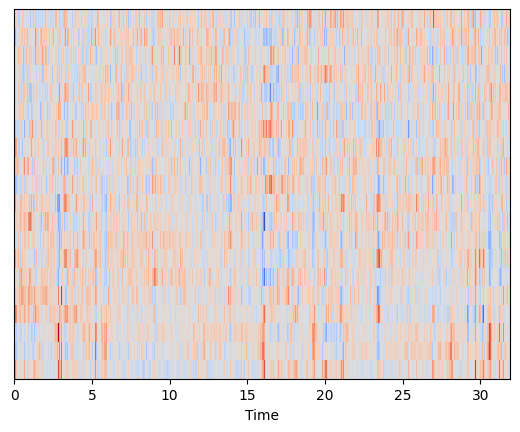

In [46]:
mfccs = sklearn.preprocessing.scale(mfccs, axis=1)
print(mfccs.mean(axis=1))
print(mfccs.var(axis=1))
librosa.display.specshow(mfccs, sr=sr, x_axis='time')

# 1) Random Forest / Gradient Boosting (XGBoost/LightGBM)

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from tqdm import tqdm

# Fungsi untuk ekstraksi fitur rata-rata MFCC agar panjangnya seragam
def extract_features(file_path):
    try:
        audio, sr = librosa.load(file_path, duration=10, res_type='kaiser_fast')
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
        return np.mean(mfccs.T, axis=0)
    except Exception as e:
        return None

# Ambil 21 spesies teratas untuk contoh cepat
top_21_species = filtered_bird_species_counts.head(21)['Bird Species'].tolist()

X = []
y = []

print(f'Mengekstrak fitur untuk spesies: {top_21_species}')

for species in top_21_species:
    species_dir = os.path.join(path, 'Voice of Birds', 'Voice of Birds', f'{species}_sound')
    files = glob(os.path.join(species_dir, '*.mp3'))

    for f in tqdm(files, desc=f'Processing {species}'):
        feat = extract_features(f)
        if feat is not None:
            X.append(feat)
            y.append(species)

X = np.array(X)
y = np.array(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluasi
y_pred = model.predict(X_test)
print('\nAkurasi:', accuracy_score(y_test, y_pred))
print('--- LAPORAN KLASIFIKASI: Random Forest / Gradient Boosting ---')
print(classification_report(y_test, y_pred))

Mengekstrak fitur untuk spesies: ['Great Tinamou', 'Solitary Tinamou', 'White-throated Tinamou', 'Grey Tinamou', 'Small-billed Tinamou', "Bartlett's Tinamou", 'Red-legged Tinamou', 'Thicket Tinamou', 'Yellow-legged Tinamou', 'Black-capped Tinamou', 'Undulated Tinamou', 'Pale-browed Tinamou', 'Brazilian Tinamou', 'Brown Tinamou', 'Cinereous Tinamou', 'Little Tinamou', 'Tawny-breasted Tinamou', 'Highland Tinamou', 'Andean Tinamou', 'Red-winged Tinamou', 'Tataupa Tinamou']


Processing Small-billed Tinamou: 100%|██████████| 30/30 [00:05<00:00,  5.51it/s]
Processing Bartlett's Tinamou: 0it [00:00, ?it/s]
Processing Tataupa Tinamou: 100%|██████████| 30/30 [00:06<00:00,  4.66it/s]



Akurasi: 0.7333333333333333
--- LAPORAN KLASIFIKASI: Random Forest / Gradient Boosting ---
                        precision    recall  f1-score   support

        Andean Tinamou       0.22      0.33      0.27         6
  Black-capped Tinamou       0.80      0.67      0.73         6
     Brazilian Tinamou       0.75      1.00      0.86         6
         Brown Tinamou       0.50      0.50      0.50         6
     Cinereous Tinamou       1.00      1.00      1.00         6
         Great Tinamou       0.83      0.83      0.83         6
          Grey Tinamou       0.60      0.50      0.55         6
      Highland Tinamou       0.83      0.83      0.83         6
        Little Tinamou       1.00      0.83      0.91         6
   Pale-browed Tinamou       0.71      0.83      0.77         6
    Red-legged Tinamou       0.67      0.67      0.67         6
    Red-winged Tinamou       0.80      0.67      0.73         6
  Small-billed Tinamou       0.83      0.83      0.83         6
      Solit

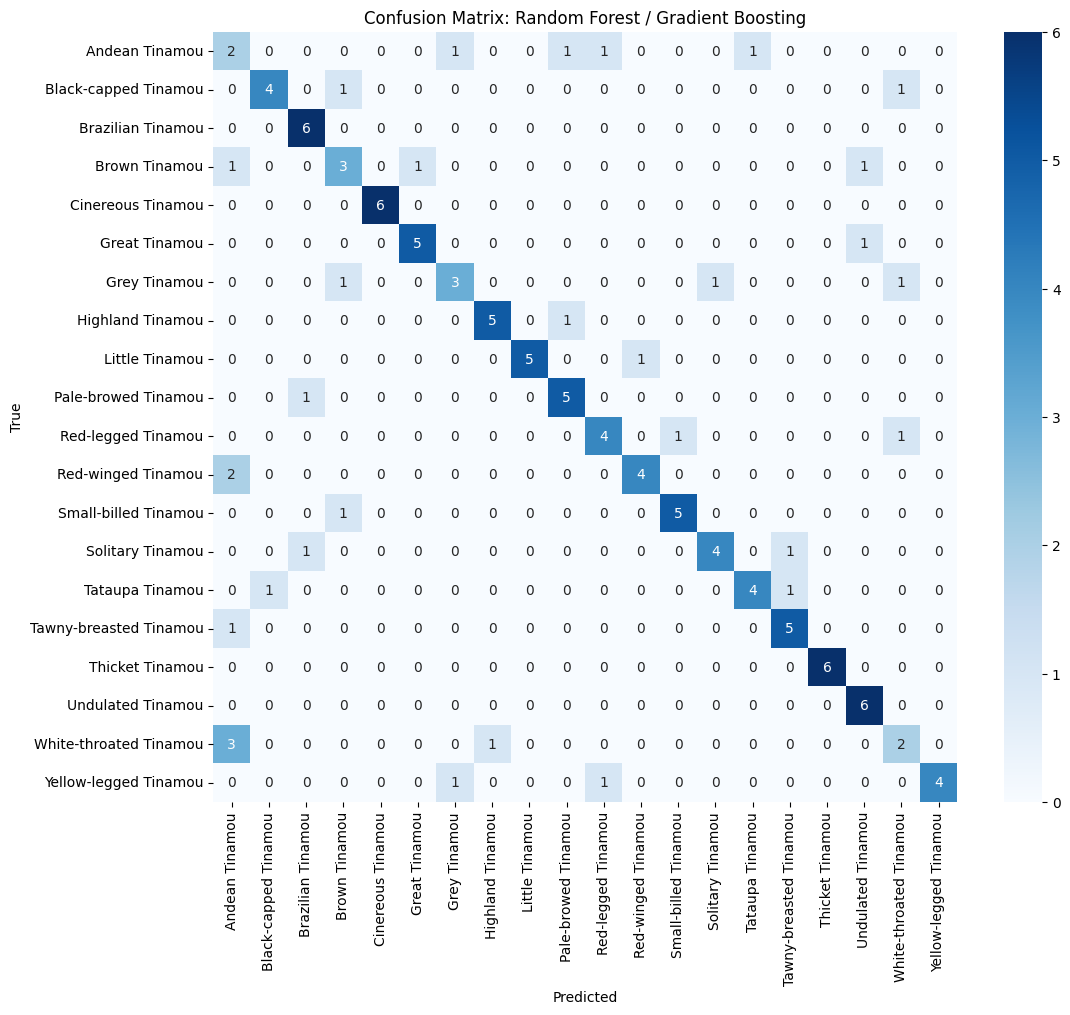

In [49]:
# Confusion Matrix for Random Forest
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix: Random Forest / Gradient Boosting')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 2) Support Vector Machine

In [51]:
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Ambil 21 spesies teratas
top_21_species = filtered_bird_species_counts.head(21)['Bird Species'].tolist()

X_flat = [] # Untuk SVM (rata-rata MFCC)
X_seq = []  # Untuk RNN (sequence MFCC)
y_labels = []

print(f'Mengekstrak fitur untuk 21 spesies...')

for species in top_21_species:
    species_dir = os.path.join(path, 'Voice of Birds', 'Voice of Birds', f'{species}_sound')
    files = glob(os.path.join(species_dir, '*.mp3'))

    for f in tqdm(files, desc=f'Processing {species}'):
        try:
            audio, sr = librosa.load(f, duration=5, res_type='kaiser_fast')
            mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

            # Fitur Flat (Mean) untuk SVM
            X_flat.append(np.mean(mfccs.T, axis=0))

            # Fitur Sequence untuk RNN (Padding/Truncate ke panjang tetap, misal 216 frames)
            pad_width = 216 - mfccs.shape[1]
            if pad_width > 0:
                mfccs_padded = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
            else:
                mfccs_padded = mfccs[:, :216]
            X_seq.append(mfccs_padded.T)

            y_labels.append(species)
        except:
            continue

X_flat = np.array(X_flat)
X_seq = np.array(X_seq)
y_labels = np.array(y_labels)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)

print(f'Selesai. Total sampel: {len(y_labels)}')


Mengekstrak fitur untuk 21 spesies...


Processing Small-billed Tinamou: 100%|██████████| 30/30 [00:03<00:00,  8.39it/s]
Processing Bartlett's Tinamou: 0it [00:00, ?it/s]
Processing Tataupa Tinamou: 100%|██████████| 30/30 [00:03<00:00,  7.58it/s]

Selesai. Total sampel: 600


In [52]:
print("--- Implementasi SVM ---")
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(X_flat, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

scaler = StandardScaler()
X_train_svm = scaler.fit_transform(X_train_svm)
X_test_svm = scaler.transform(X_test_svm)

svm_model = SVC(kernel='rbf', C=10, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

svm_pred = svm_model.predict(X_test_svm)
print(f'Akurasi SVM: {accuracy_score(y_test_svm, svm_pred):.2%}')

--- Implementasi SVM ---
Akurasi SVM: 78.33%


In [53]:
from sklearn.metrics import classification_report, confusion_matrix

# 2. Laporan Klasifikasi untuk SVM
print('--- LAPORAN KLASIFIKASI: SVM ---')
print(classification_report(y_test_svm, svm_pred, target_names=le.classes_))

--- LAPORAN KLASIFIKASI: SVM ---
                        precision    recall  f1-score   support

        Andean Tinamou       0.43      0.50      0.46         6
  Black-capped Tinamou       0.83      0.83      0.83         6
     Brazilian Tinamou       0.86      1.00      0.92         6
         Brown Tinamou       1.00      0.67      0.80         6
     Cinereous Tinamou       1.00      1.00      1.00         6
         Great Tinamou       0.86      1.00      0.92         6
          Grey Tinamou       0.43      0.50      0.46         6
      Highland Tinamou       0.75      1.00      0.86         6
        Little Tinamou       0.71      0.83      0.77         6
   Pale-browed Tinamou       1.00      0.83      0.91         6
    Red-legged Tinamou       0.80      0.67      0.73         6
    Red-winged Tinamou       0.67      0.67      0.67         6
  Small-billed Tinamou       0.83      0.83      0.83         6
      Solitary Tinamou       0.67      0.67      0.67         6
      

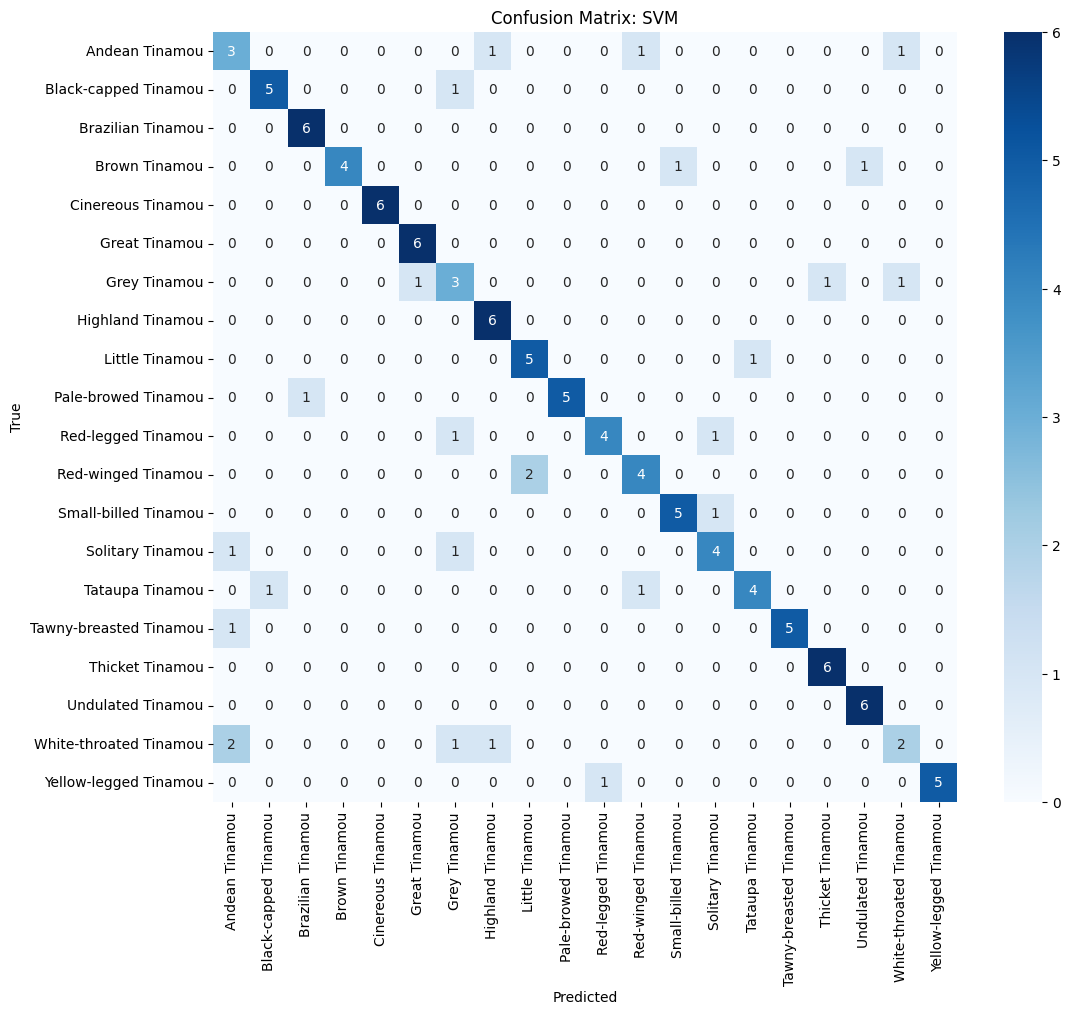

In [54]:
# Confusion Matrix for SVM
cm_svm = confusion_matrix(y_test_svm, svm_pred, labels=np.arange(len(le.classes_)))
plt.figure(figsize=(12, 10))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: SVM')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()



# 3) Recurrent Neural Networks (LSTM/GRU)

In [ ]:
print("--- Implementasi RNN (LSTM) ---")
X_train_rnn, X_test_rnn, y_train_rnn, y_test_rnn = train_test_split(X_seq, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

model_rnn = Sequential([
    LSTM(64, input_shape=(X_seq.shape[1], X_seq.shape[2]), return_sequences=True),
    LSTM(64),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(le.classes_), activation='softmax') # Ubah menjadi 21 kelas
])

model_rnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model_rnn.fit(X_train_rnn, y_train_rnn, epochs=30, batch_size=32, validation_data=(X_test_rnn, y_test_rnn), verbose=1)

loss, acc = model_rnn.evaluate(X_test_rnn, y_test_rnn, verbose=0)
print(f'\nAkurasi RNN (LSTM): {acc:.2%}')

# Menemukan akurasi validasi terbaik dari riwayat pelatihan
best_val_accuracy = max(history.history['val_accuracy'])
print(f'Akurasi Validasi Terbaik selama Pelatihan: {best_val_accuracy:.2%}')

--- Implementasi RNN (LSTM) ---
Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 233ms/step - accuracy: 0.0938 - loss: 2.9629 - val_accuracy: 0.1750 - val_loss: 2.9068
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 266ms/step - accuracy: 0.2021 - loss: 2.8406 - val_accuracy: 0.2083 - val_loss: 2.8067
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 188ms/step - accuracy: 0.2604 - loss: 2.6994 - val_accuracy: 0.3250 - val_loss: 2.6570
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 185ms/step - accuracy: 0.2812 - loss: 2.4884 - val_accuracy: 0.3333 - val_loss: 2.5046
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 272ms/step - accuracy: 0.3562 - loss: 2.3369 - val_accuracy: 0.4167 - val_loss: 2.2970
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 189ms/step - accuracy: 0.4229 - loss: 2.1096 - val_accuracy: 0.4583 - val_loss: 2.1410
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 185ms/step - accuracy: 0.4417 - loss: 1.9220 - val_accuracy: 0.5000 - val_loss: 1.9568
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 187ms/step - accuracy: 0.4812 -

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
# 3. Laporan Klasifikasi untuk RNN (LSTM)
print('\n--- LAPORAN KLASIFIKASI: RNN (LSTM) ---')
# Mendapatkan probabilitas prediksi
y_pred_rnn_probs = model_rnn.predict(X_test_rnn, verbose=0)
# Mengambil index dengan probabilitas tertinggi
y_pred_rnn_indices = np.argmax(y_pred_rnn_probs, axis=1)

print(classification_report(y_test_rnn, y_pred_rnn_indices, target_names=le.classes_))


--- LAPORAN KLASIFIKASI: RNN (LSTM) ---
                        precision    recall  f1-score   support

        Andean Tinamou       0.75      1.00      0.86         6
  Black-capped Tinamou       0.83      0.83      0.83         6
     Brazilian Tinamou       1.00      0.67      0.80         6
         Brown Tinamou       0.86      1.00      0.92         6
     Cinereous Tinamou       0.67      1.00      0.80         6
         Great Tinamou       0.75      0.50      0.60         6
          Grey Tinamou       0.71      0.83      0.77         6
      Highland Tinamou       0.56      0.83      0.67         6
        Little Tinamou       1.00      0.83      0.91         6
   Pale-browed Tinamou       0.50      0.33      0.40         6
    Red-legged Tinamou       0.67      0.67      0.67         6
    Red-winged Tinamou       0.60      1.00      0.75         6
  Small-billed Tinamou       0.67      0.67      0.67         6
      Solitary Tinamou       1.00      0.50      0.67         

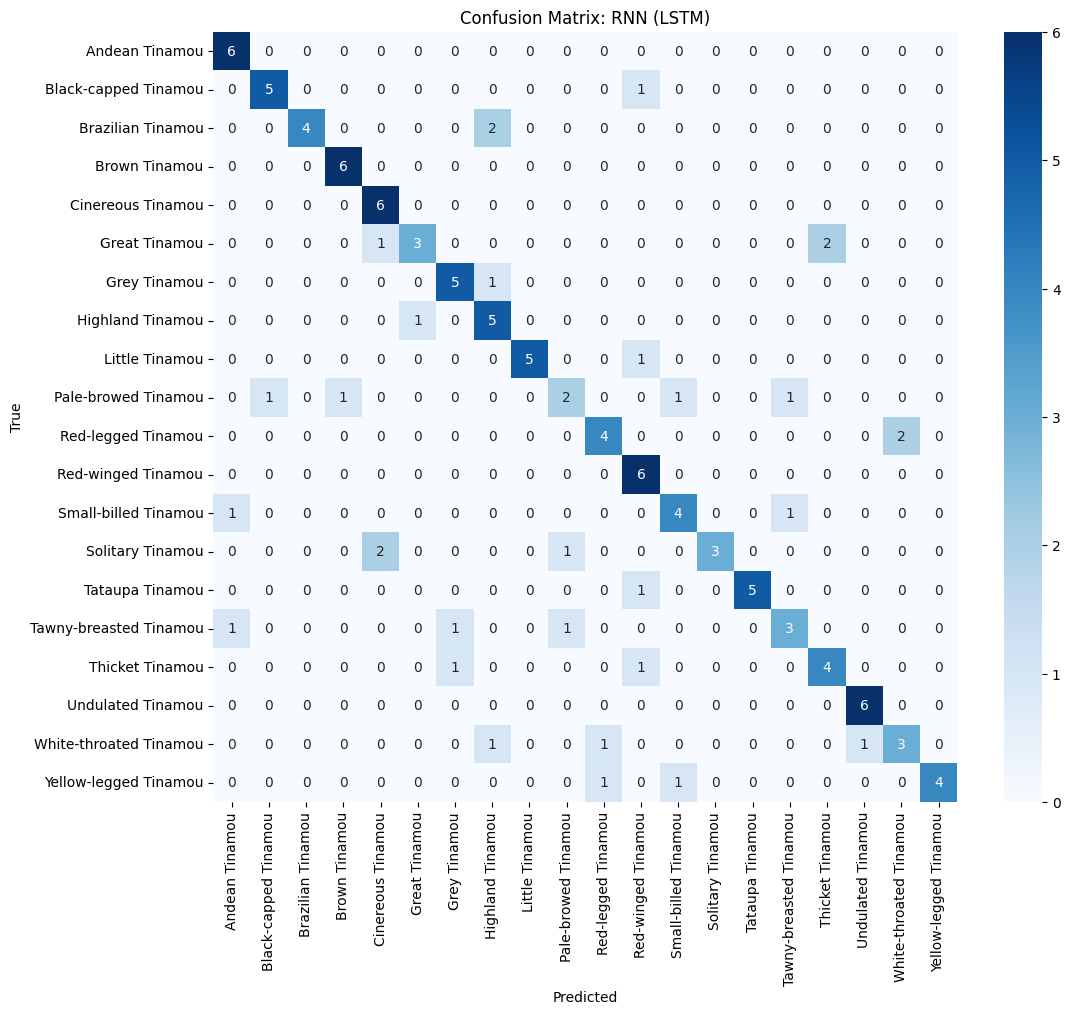

In [ ]:
# Confusion Matrix for RNN (LSTM)
cm_rnn = confusion_matrix(y_test_rnn, y_pred_rnn_indices, labels=np.arange(len(le.classes_)))
plt.figure(figsize=(12, 10))
sns.heatmap(cm_rnn, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: RNN (LSTM)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

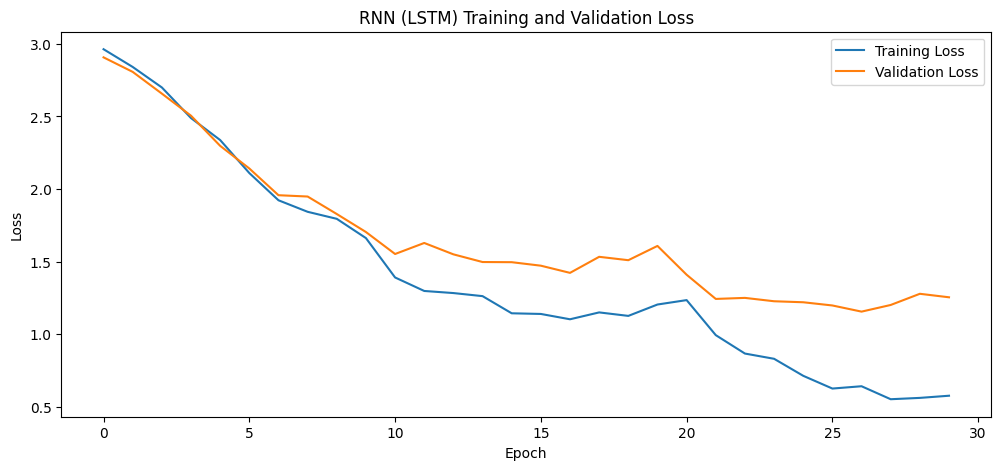

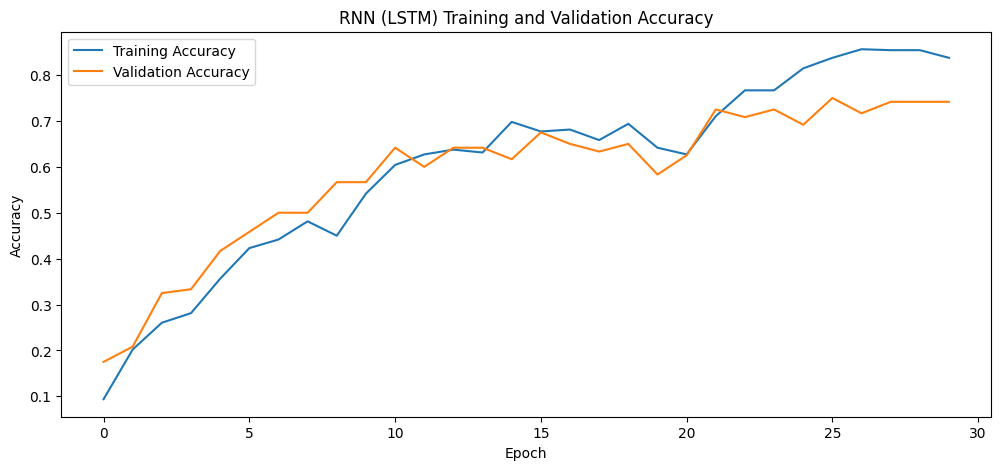

In [ ]:
# Plot Training & Validation Loss for RNN (LSTM)
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('RNN (LSTM) Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot Training & Validation Accuracy for RNN (LSTM)
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('RNN (LSTM) Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 4) Gradient Boosting (XGBoost)

In [55]:
print("--- Implementasi Gradient Boosting (XGBoost) ---")
import xgboost as xgb

# Menggunakan data yang sudah discale dari SVM
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = X_train_svm, X_test_svm, y_train_svm, y_test_svm

xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=len(le.classes_), eval_metric='mlogloss', use_label_encoder=False, random_state=42)
xgb_model.fit(X_train_xgb, y_train_xgb)

xgb_pred = xgb_model.predict(X_test_xgb)
print(f'Akurasi XGBoost: {accuracy_score(y_test_xgb, xgb_pred):.2%}')

--- Implementasi Gradient Boosting (XGBoost) ---
Akurasi XGBoost: 71.67%


In [56]:
from sklearn.metrics import confusion_matrix
print('--- LAPORAN KLASIFIKASI: XGBoost ---')
print(classification_report(y_test_xgb, xgb_pred, target_names=le.classes_))

--- LAPORAN KLASIFIKASI: XGBoost ---
                        precision    recall  f1-score   support

        Andean Tinamou       0.50      0.33      0.40         6
  Black-capped Tinamou       0.80      0.67      0.73         6
     Brazilian Tinamou       0.83      0.83      0.83         6
         Brown Tinamou       0.67      0.67      0.67         6
     Cinereous Tinamou       1.00      1.00      1.00         6
         Great Tinamou       0.67      0.67      0.67         6
          Grey Tinamou       0.60      0.50      0.55         6
      Highland Tinamou       0.71      0.83      0.77         6
        Little Tinamou       1.00      0.83      0.91         6
   Pale-browed Tinamou       0.71      0.83      0.77         6
    Red-legged Tinamou       0.67      0.67      0.67         6
    Red-winged Tinamou       0.80      0.67      0.73         6
  Small-billed Tinamou       0.62      0.83      0.71         6
      Solitary Tinamou       0.44      0.67      0.53         6
  

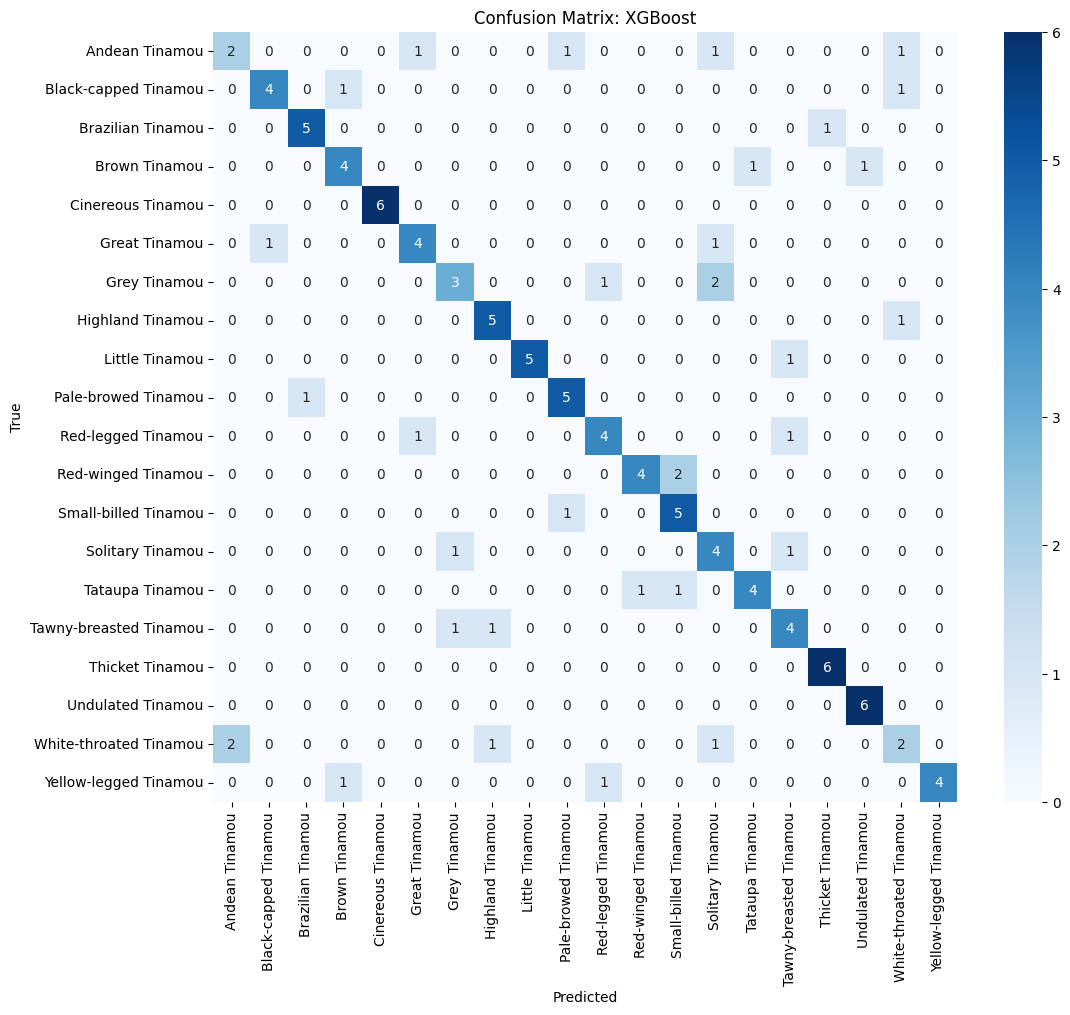

In [57]:
# Confusion Matrix for XGBoost
cm_xgb = confusion_matrix(y_test_xgb, xgb_pred, labels=np.arange(len(le.classes_)))
plt.figure(figsize=(12, 10))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: XGBoost')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 5) Feedforward Neural Network (FNN)

In [ ]:
print("--- Implementasi Feedforward Neural Network (FNN) ---")

# Menggunakan data yang sudah discale dari SVM
X_train_fnn, X_test_fnn, y_train_fnn, y_test_fnn = X_train_svm, X_test_svm, y_train_svm, y_test_svm

model_fnn = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_fnn.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(le.classes_), activation='softmax')
])

model_fnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_fnn = model_fnn.fit(X_train_fnn, y_train_fnn, epochs=30, batch_size=32, validation_data=(X_test_fnn, y_test_fnn), verbose=1)

loss_fnn, acc_fnn = model_fnn.evaluate(X_test_fnn, y_test_fnn, verbose=0)
print(f'\nAkurasi FNN: {acc_fnn:.2%}')

best_val_accuracy_fnn = max(history_fnn.history['val_accuracy'])
print(f'Akurasi Validasi Terbaik selama Pelatihan FNN: {best_val_accuracy_fnn:.2%}')

--- Implementasi Feedforward Neural Network (FNN) ---
Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.0437 - loss: 3.1302 - val_accuracy: 0.1583 - val_loss: 2.8204
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1063 - loss: 2.8610 - val_accuracy: 0.2917 - val_loss: 2.6708
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1604 - loss: 2.7184 - val_accuracy: 0.3583 - val_loss: 2.5453
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2521 - loss: 2.5840 - val_accuracy: 0.4833 - val_loss: 2.4083
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3021 - loss: 2.4047 - val_accuracy: 0.4833 - val_loss: 2.2625
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3667 - loss: 2.2809 - val_accuracy: 0.5000 - val_loss: 2.1199
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3979 - loss: 2.1760 - val_accuracy: 0.5167 - val_loss: 1.9761
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0

In [ ]:
from sklearn.metrics import confusion_matrix
print('\n--- LAPORAN KLASIFIKASI: FNN ---')
y_pred_fnn_probs = model_fnn.predict(X_test_fnn, verbose=0)
y_pred_fnn_indices = np.argmax(y_pred_fnn_probs, axis=1)
print(classification_report(y_test_fnn, y_pred_fnn_indices, target_names=le.classes_))


--- LAPORAN KLASIFIKASI: FNN ---
                        precision    recall  f1-score   support

        Andean Tinamou       0.50      0.67      0.57         6
  Black-capped Tinamou       1.00      0.50      0.67         6
     Brazilian Tinamou       0.71      0.83      0.77         6
         Brown Tinamou       0.67      1.00      0.80         6
     Cinereous Tinamou       1.00      1.00      1.00         6
         Great Tinamou       0.75      0.50      0.60         6
          Grey Tinamou       0.62      0.83      0.71         6
      Highland Tinamou       0.62      0.83      0.71         6
        Little Tinamou       1.00      1.00      1.00         6
   Pale-browed Tinamou       1.00      0.50      0.67         6
    Red-legged Tinamou       0.67      0.33      0.44         6
    Red-winged Tinamou       0.83      0.83      0.83         6
  Small-billed Tinamou       0.80      0.67      0.73         6
      Solitary Tinamou       0.50      0.33      0.40         6
     

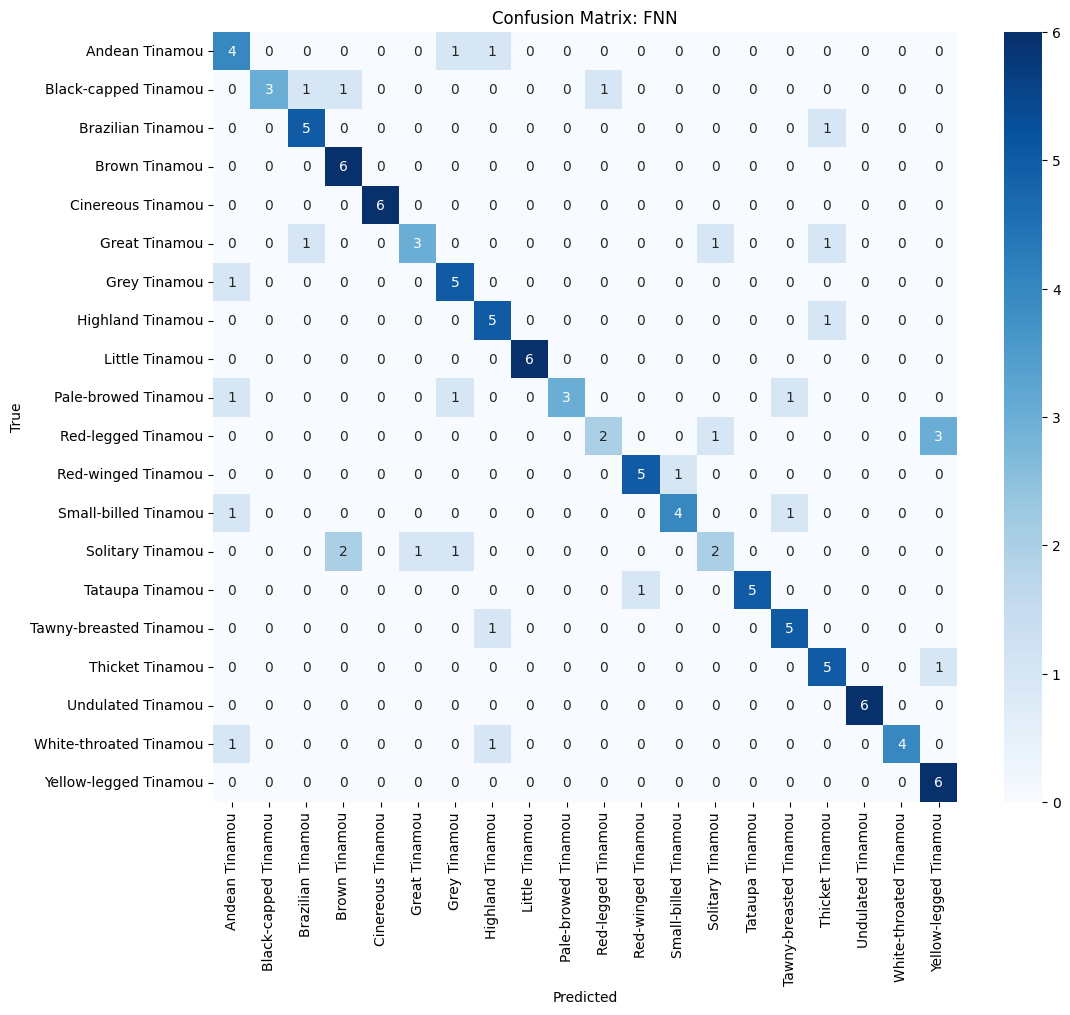

In [ ]:
# Confusion Matrix for FNN
cm_fnn = confusion_matrix(y_test_fnn, y_pred_fnn_indices, labels=np.arange(len(le.classes_)))
plt.figure(figsize=(12, 10))
sns.heatmap(cm_fnn, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: FNN')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

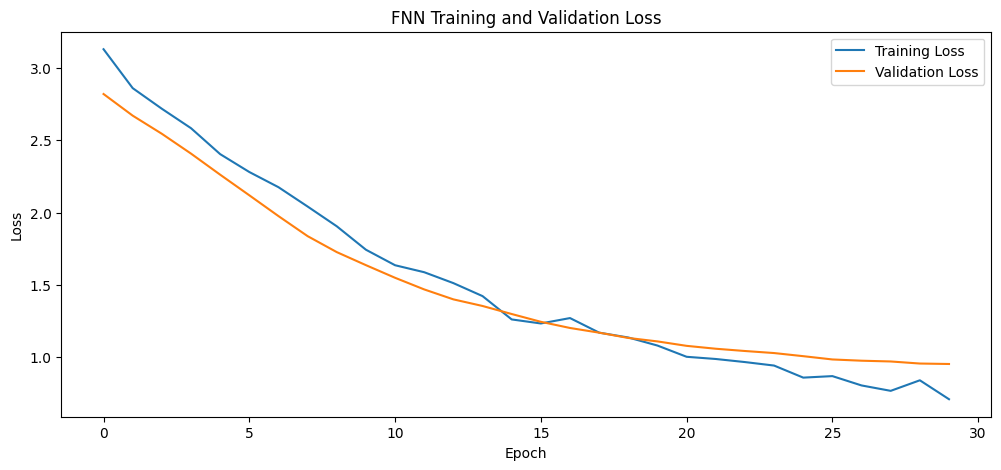

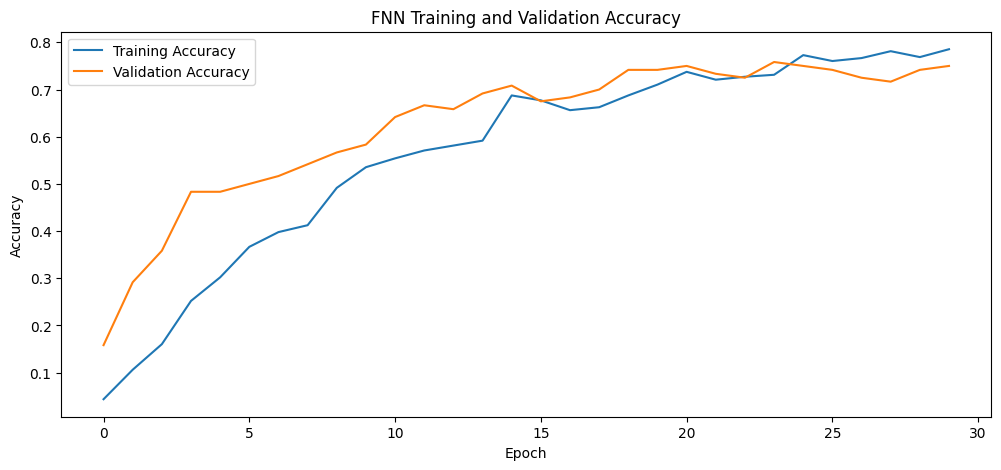

In [ ]:
# Plot Training & Validation Loss for FNN
plt.figure(figsize=(12, 5))
plt.plot(history_fnn.history['loss'], label='Training Loss')
plt.plot(history_fnn.history['val_loss'], label='Validation Loss')
plt.title('FNN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot Training & Validation Accuracy for FNN
plt.figure(figsize=(12, 5))
plt.plot(history_fnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_fnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('FNN Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 6) Gated Recurrent Unit (GRU)

In [ ]:
print("--- Implementasi GRU ---")
from tensorflow.keras.layers import GRU
from sklearn.metrics import confusion_matrix

# Menggunakan data sekuensial dari RNN
X_train_gru, X_test_gru, y_train_gru, y_test_gru = X_train_rnn, X_test_rnn, y_train_rnn, y_test_rnn

model_gru = Sequential([
    GRU(64, input_shape=(X_seq.shape[1], X_seq.shape[2]), return_sequences=True),
    GRU(64),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(le.classes_), activation='softmax')
])

model_gru.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_gru = model_gru.fit(X_train_gru, y_train_gru, epochs=30, batch_size=32, validation_data=(X_test_gru, y_test_gru), verbose=1)

loss_gru, acc_gru = model_gru.evaluate(X_test_gru, y_test_gru, verbose=0)
print(f'\nAkurasi GRU: {acc_gru:.2%}')

best_val_accuracy_gru = max(history_gru.history['val_accuracy'])
print(f'Akurasi Validasi Terbaik selama Pelatihan GRU: {best_val_accuracy_gru:.2%}')

--- Implementasi GRU ---
Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 347ms/step - accuracy: 0.0708 - loss: 3.0268 - val_accuracy: 0.1583 - val_loss: 2.9163
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 222ms/step - accuracy: 0.1458 - loss: 2.8779 - val_accuracy: 0.2833 - val_loss: 2.8187
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 207ms/step - accuracy: 0.2208 - loss: 2.7637 - val_accuracy: 0.2750 - val_loss: 2.7115
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 296ms/step - accuracy: 0.3042 - loss: 2.6329 - val_accuracy: 0.3167 - val_loss: 2.5821
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 212ms/step - accuracy: 0.3500 - loss: 2.4695 - val_accuracy: 0.3750 - val_loss: 2.4228
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 209ms/step - accuracy: 0.3688 - loss: 2.3208 - val_accuracy: 0.3917 - val_loss: 2.2299
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 314ms/step - accuracy: 0.4104 - loss: 2.0876 - val_accuracy: 0.4083 - val_loss: 2.0631
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 215ms/step - accuracy: 0.4917 - loss: 

In [ ]:
print('\n--- LAPORAN KLASIFIKASI: GRU ---')
y_pred_gru_probs = model_gru.predict(X_test_gru, verbose=0)
y_pred_gru_indices = np.argmax(y_pred_gru_probs, axis=1)
print(classification_report(y_test_gru, y_pred_gru_indices, target_names=le.classes_))


--- LAPORAN KLASIFIKASI: GRU ---


                        precision    recall  f1-score   support

        Andean Tinamou       0.62      0.83      0.71         6
  Black-capped Tinamou       1.00      0.50      0.67         6
     Brazilian Tinamou       0.71      0.83      0.77         6
         Brown Tinamou       0.67      0.67      0.67         6
     Cinereous Tinamou       1.00      1.00      1.00         6
         Great Tinamou       0.80      0.67      0.73         6
          Grey Tinamou       0.50      0.83      0.62         6
      Highland Tinamou       0.71      0.83      0.77         6
        Little Tinamou       1.00      1.00      1.00         6
   Pale-browed Tinamou       0.60      0.50      0.55         6
    Red-legged Tinamou       0.50      0.67      0.57         6
    Red-winged Tinamou       1.00      0.67      0.80         6
  Small-billed Tinamou       0.83      0.83      0.83         6
      Solitary Tinamou       0.60      0.50      0.55         6
       Tataupa Tinamou       0.71      

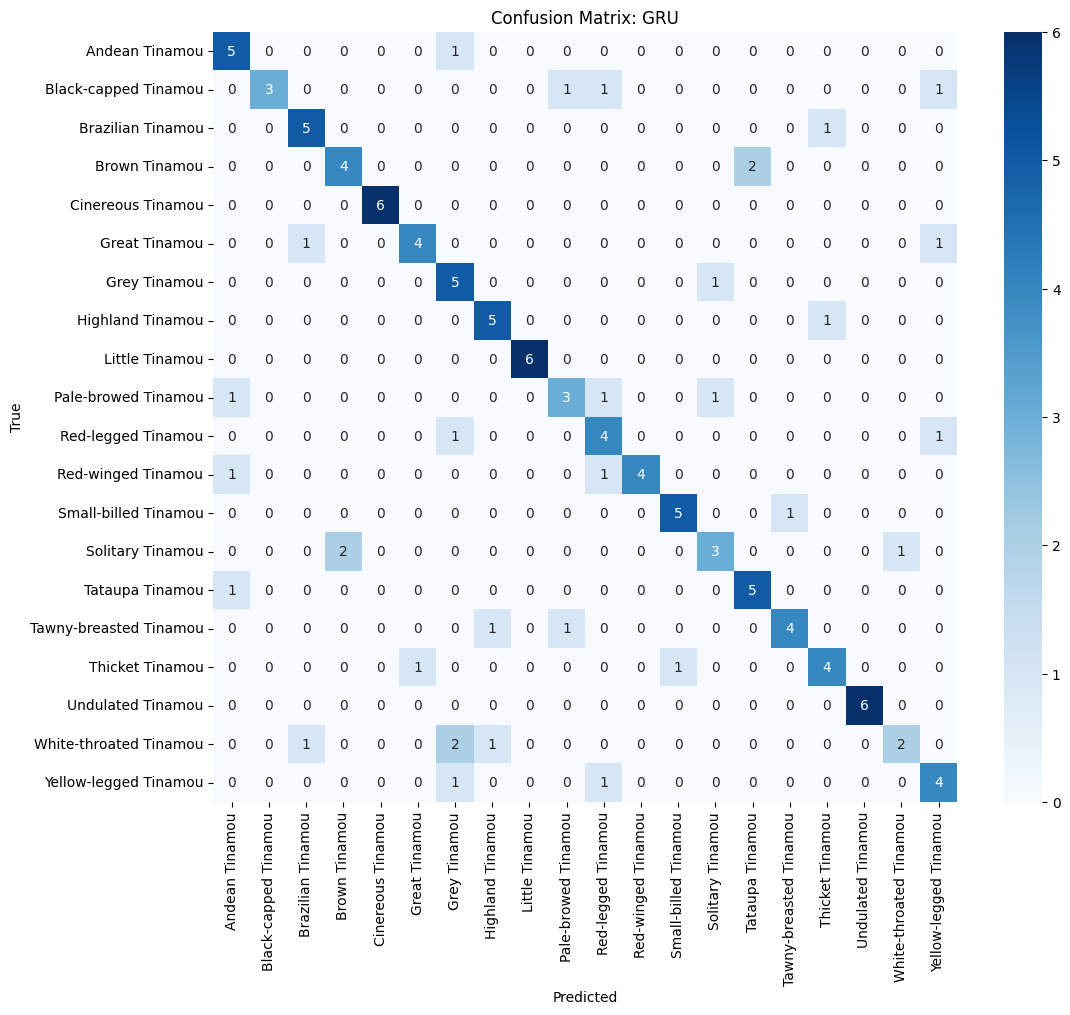

In [ ]:
# Confusion Matrix for GRU
cm_gru = confusion_matrix(y_test_gru, y_pred_gru_indices, labels=np.arange(len(le.classes_)))
plt.figure(figsize=(12, 10))
sns.heatmap(cm_gru, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: GRU')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

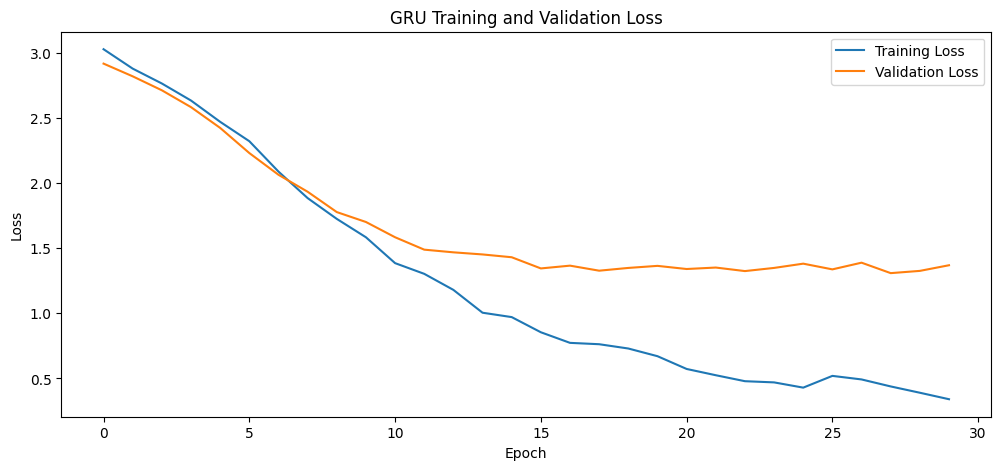

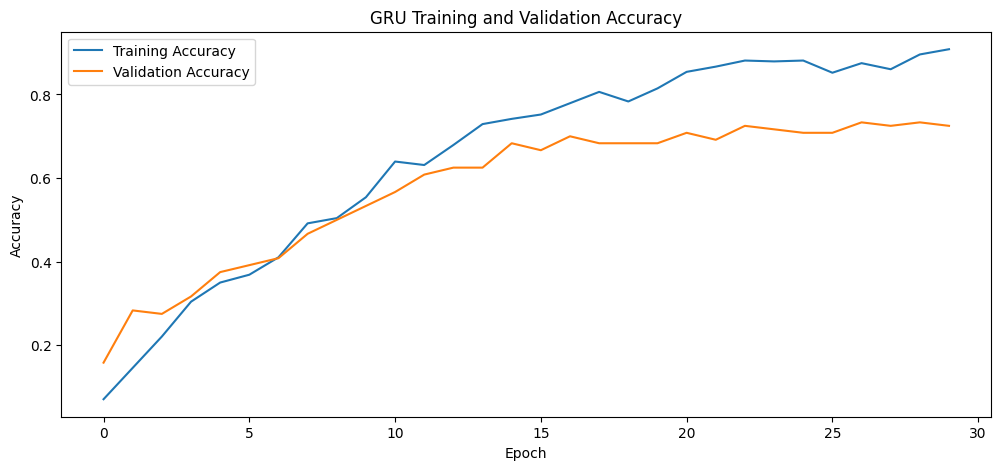

In [ ]:
# Plot Training & Validation Loss for GRU
plt.figure(figsize=(12, 5))
plt.plot(history_gru.history['loss'], label='Training Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')
plt.title('GRU Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot Training & Validation Accuracy for GRU
plt.figure(figsize=(12, 5))
plt.plot(history_gru.history['accuracy'], label='Training Accuracy')
plt.plot(history_gru.history['val_accuracy'], label='Validation Accuracy')
plt.title('GRU Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Model Comparison - Average Accuracy

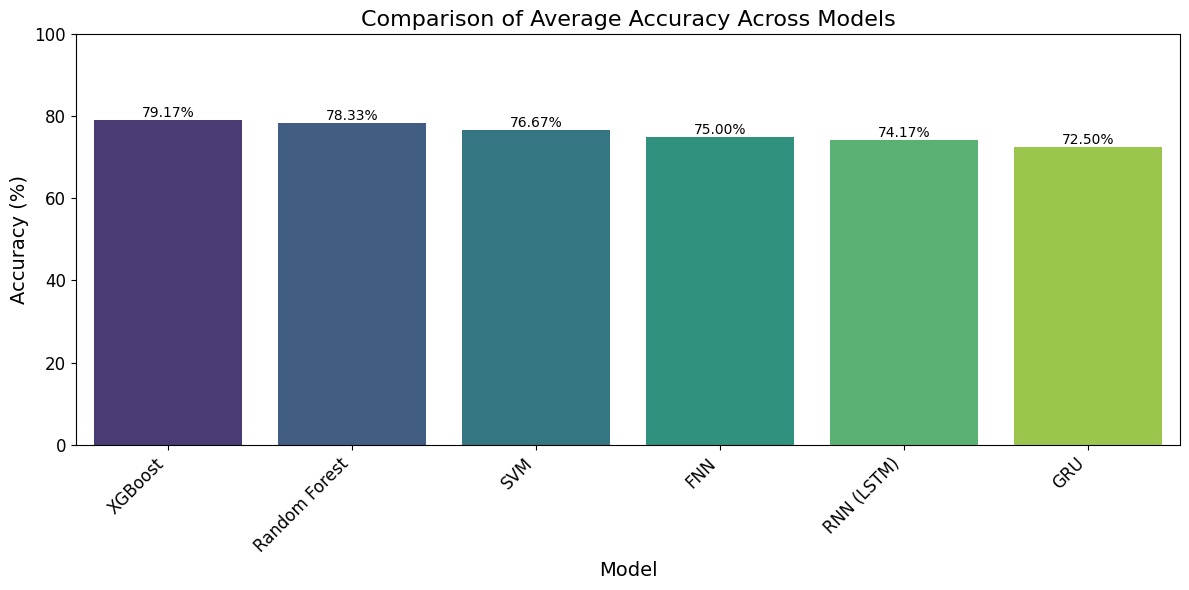

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Model accuracies (extracted from previous outputs)
model_names = ['Random Forest', 'SVM', 'XGBoost', 'FNN', 'RNN (LSTM)', 'GRU']
accuracies = [78.33, 76.67, 79.17, 75.00, 74.17, 72.50]

# Create a DataFrame for plotting
accuracy_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy (%)': accuracies
})

# Sort by accuracy for better visualization
accuracy_df = accuracy_df.sort_values(by='Accuracy (%)', ascending=False)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Model', y='Accuracy (%)', data=accuracy_df, palette='viridis')

plt.title('Comparison of Average Accuracy Across Models', fontsize=16)
plt.xlabel('Model', fontsize=14)
plt.ylabel('Accuracy (%)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, 100) # Set y-axis limit for percentages

# Add accuracy values on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', label_type='edge', fontsize=10)

plt.tight_layout()
plt.show()